##sequential workflow

In [ ]:
# step 1: import necessary modules
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, MessagesState, START, END


In [ ]:
# step 2:Initialize the chat model
import os 
from dotenv import load_dotenv 
load_dotenv()

from langchain.chat_models import init_chat_model
api_key = os.getenv("GOOGLE_API_KEY")

chat_model= init_chat_model (
    "google_genai:gemini-flash-latest", 
    api_key=api_key,
    temperature=0.7
)


In [ ]:

#step 3:define state
class QuestionAnsweringState(TypedDict):
    question: str
    answer: str

In [ ]:
# step 4 :define node function
def question_answering_step(state: QuestionAnsweringState) -> QuestionAnsweringState:
    question=state['question']
    prompt=f"Answer the following question: {question}"
    answer=chat_model.invoke(prompt).content
    state['answer']=answer
    return state

In [ ]:
#step 6 : define graph 
#step 6.1 initialize graph with state type
graph=StateGraph(QuestionAnsweringState)
#step 6.2 add nodes
graph.add_node('question_answering_step',question_answering_step)
#step 6.3 define edges
graph.add_edge(START,'question_answering_step')
# step 6.3 define edges 
graph.add_edge('question_answering_step',END)
#step 6.4 compile graph to workflow
workflow=graph.compile()
# step 7: invoke workflow with initial state
initial_state={'question':'capital of jharkhand and explain about it in brief like tour guide would do'}
# step 7.1 invoke workflow with initial state
final_state=workflow.invoke(initial_state)
# step 7.2: print final state answer
print (final_state['answer'])

The capital of Jharkhand is **Ranchi**.

---

## Welcome to Ranchi: The City of Waterfalls!

*(Imagine a brisk, enthusiastic tour guide speaking)*

"Hello everyone, and welcome to Ranchi! You are standing in the heart of Jharkhand, a city often affectionately called the **'City of Waterfalls'** and historically known as the **'Summer Capital'** during the British Raj due to its pleasant, elevated location on the Chota Nagpur Plateau.

Ranchi is a perfect blend of lush nature, spiritual history, and modern life—it’s the gateway to the tribal heartland of India!

### 🏞️ The Natural Wonders (Get Your Cameras Ready!)

If you love nature, Ranchi is your paradise. We are surrounded by breathtaking cascades:

*   **Hundru Falls:** A magnificent sight where the Subarnarekha River plunges 98 meters. It’s a true spectacle, especially right after the monsoon.
*   **Jonha Falls (Gautam Dhara):** Known for its tranquil setting and the legend associated with the Buddha. You have to climb down quite 

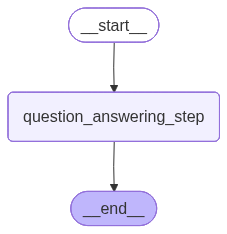

In [21]:
#visualize graph method 1
graph.compile()

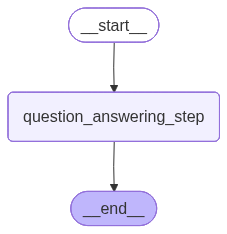

In [22]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png()) #method 2 visualize